# EDA - Google Play Store Dataset
It is very complex because it needs data preprocessing and also the data is messy

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("googleplaystore.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [42]:
df.shape
df.info()
df.head()
df.describe()          # numeric summary
df.describe(include='object')  # categorical summary
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.2 MB


C:\Users\ssa56\AppData\Local\Temp\ipykernel_2540\1285260646.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')  # categorical summary


App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

In [43]:
(df.isnull().sum() / df.count()) * 100


App                0.000000
Category           0.000000
Rating            15.736095
Reviews            0.000000
Size               0.000000
Installs           0.000000
Type               0.009225
Price              0.000000
Content Rating     0.009225
Genres             0.000000
Last Updated       0.000000
Current Ver        0.073848
Android Ver        0.027680
dtype: float64

## Data Cleaning
We will fix null values. Rating has a lot of it and other 4 has very little. 
We will create a new dataframe for precaution

In [44]:
df_copy = df.copy()

First Clean reviews. It is non numeric so lets see how many values are non numeric

In [45]:
df['Reviews'].str.isnumeric().sum()
df[~df['Reviews'].str.isnumeric()]
df_copy.drop(index=df_copy.index[10472], inplace=True)
df_copy['Reviews'] = df_copy['Reviews'].astype(int)
print(df_copy['Reviews'].dtype)

int64


Now clean size. Standardize all values into K since its suitable. And remove k as suffix since now we know every value is in k

In [46]:
df_copy['Size'] = df_copy['Size'].str.replace('M','000')
df_copy['Size'] = df_copy['Size'].str.replace('k','')
df_copy['Size'] = df_copy['Size'].replace('Varies with device', np.nan)
df_copy['Size'].astype(float)
df_copy['Size'].unique()

<ArrowStringArray>
[ '19000',  '14000', '8.7000',  '25000', '2.8000', '5.6000',  '29000',
  '33000', '3.1000',  '28000',
 ...
    '467',    '157',     '44',    '676',     '67',    '552',    '885',
   '1020',    '582',    '619']
Length: 461, dtype: str

Clean Install and Price. WE have to remove , + $ from them

In [47]:
print(df_copy['Installs'].unique())
print(df_copy['Price'].unique())

<ArrowStringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+',
              '0']
Length: 21, dtype: str
<ArrowStringArray>
[      '0',   '$4.99',   '$3.99',   '$6.99',   '$1.49',   '$2.99',   '$7.99',
   '$5.99',   '$3.49',   '$1.99',   '$9.99',   '$7.49',   '$0.99',   '$9.00',
   '$5.49',  '$10.00',  '$24.99',  '$11.99',  '$79.99',  '$16.99',  '$14.99',
   '$1.00',  '$29.99',  '$12.99',   '$2.49',  '$10.99',   '$1.50',  '$19.99',
  '$15.99',  '$33.99',  '$74.99',  '$39.99',   '$3.95',   '$4.49',   '$1.70',
   '$8.99',   '$2.00',   '$3.88',  '$25.99', '$399.99',  '$17.99', '$400.00',
   '$3.02',   '$1.76',   '$4.84',   '$4.77',   '$1.61',   '$2.50',   '$1.59',
   '$6.49

In [48]:
charsToRemove = ['$','+',',']
columnsToEdit = ['Installs', 'Price']
for column in columnsToEdit:
    for item in charsToRemove:
        df_copy[column] = df_copy[column].str.replace(item,'')
        
df_copy['Installs'].unique().astype(int)
df_copy['Price'].unique().astype(float)

array([  0.  ,   4.99,   3.99,   6.99,   1.49,   2.99,   7.99,   5.99,
         3.49,   1.99,   9.99,   7.49,   0.99,   9.  ,   5.49,  10.  ,
        24.99,  11.99,  79.99,  16.99,  14.99,   1.  ,  29.99,  12.99,
         2.49,  10.99,   1.5 ,  19.99,  15.99,  33.99,  74.99,  39.99,
         3.95,   4.49,   1.7 ,   8.99,   2.  ,   3.88,  25.99, 399.99,
        17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,   1.61,   2.5 ,
         1.59,   6.49,   1.29,   5.  ,  13.99, 299.99, 379.99,  37.99,
        18.99, 389.99,  19.9 ,   8.49,   1.75,  14.  ,   4.85,  46.99,
       109.99, 154.99,   3.08,   2.59,   4.8 ,   1.96,  19.4 ,   3.9 ,
         4.59,  15.46,   3.04,   4.29,   2.6 ,   3.28,   4.6 ,  28.99,
         2.95,   2.9 ,   1.97, 200.  ,  89.99,   2.56,  30.99,   3.61,
       394.99,   1.26,   1.2 ,   1.04])

Last Updated is a date column which can be broken down in 3 columns of date month year

In [49]:
df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'])
df_copy['Day'] = df_copy['Last Updated'].dt.day
df_copy['Month'] = df_copy['Last Updated'].dt.month
df_copy['Year'] = df_copy['Last Updated'].dt.year

In [50]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  str           
 1   Category        10840 non-null  str           
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            9145 non-null   str           
 5   Installs        10840 non-null  str           
 6   Type            10839 non-null  str           
 7   Price           10840 non-null  str           
 8   Content Rating  10840 non-null  str           
 9   Genres          10840 non-null  str           
 10  Last Updated    10840 non-null  datetime64[us]
 11  Current Ver     10832 non-null  str           
 12  Android Ver     10838 non-null  str           
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  Year            10

Save the Cleaned Data

In [51]:
import os
df_copy.to_csv('googleplaystore-cleaned.csv', index=False)

In [52]:
df = pd.read_csv('googleplaystore-cleaned.csv')

## Check Duplicates App
Since App is a Series (not a DataFrame), .duplicated() is called on the specific column rather than the whole object

In [53]:
df[df.duplicated(subset='App')].shape
df.drop_duplicates(subset='App', keep='first', inplace=True)

We found 1180 duplicates and then dropped them

## Identify Numerical vs Categorical Features

In [57]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','category']).columns
print(num_cols)
print(cat_cols)

Index(['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Day', 'Month',
       'Year'],
      dtype='str')
Index(['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='str')


C:\Users\ssa56\AppData\Local\Temp\ipykernel_2540\3735315816.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category']).columns


Find distribution of each categorical feature
Since its not 1 column but multiple ones, we loop through each one.

In [68]:
for col in cat_cols:
    print(df[col].value_counts(normalize=True)*100)

App
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
Pixel Draw - Number Art Coloring Book                 0.010353
                                                        ...   
Sya9a Maroc - FR                                      0.010353
Fr. Mike Schmitz Audio Teachings                      0.010353
Parkinson Exercices FR                                0.010353
The SCP Foundation DB fr nn5n                         0.010353
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Name: proportion, Length: 9659, dtype: float64
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.892743
PRODUCTIVITY            3.872036
LIFESTYLE       

## UNIVARIATE ANALYSIS
We will do analysis on each numerical features individually

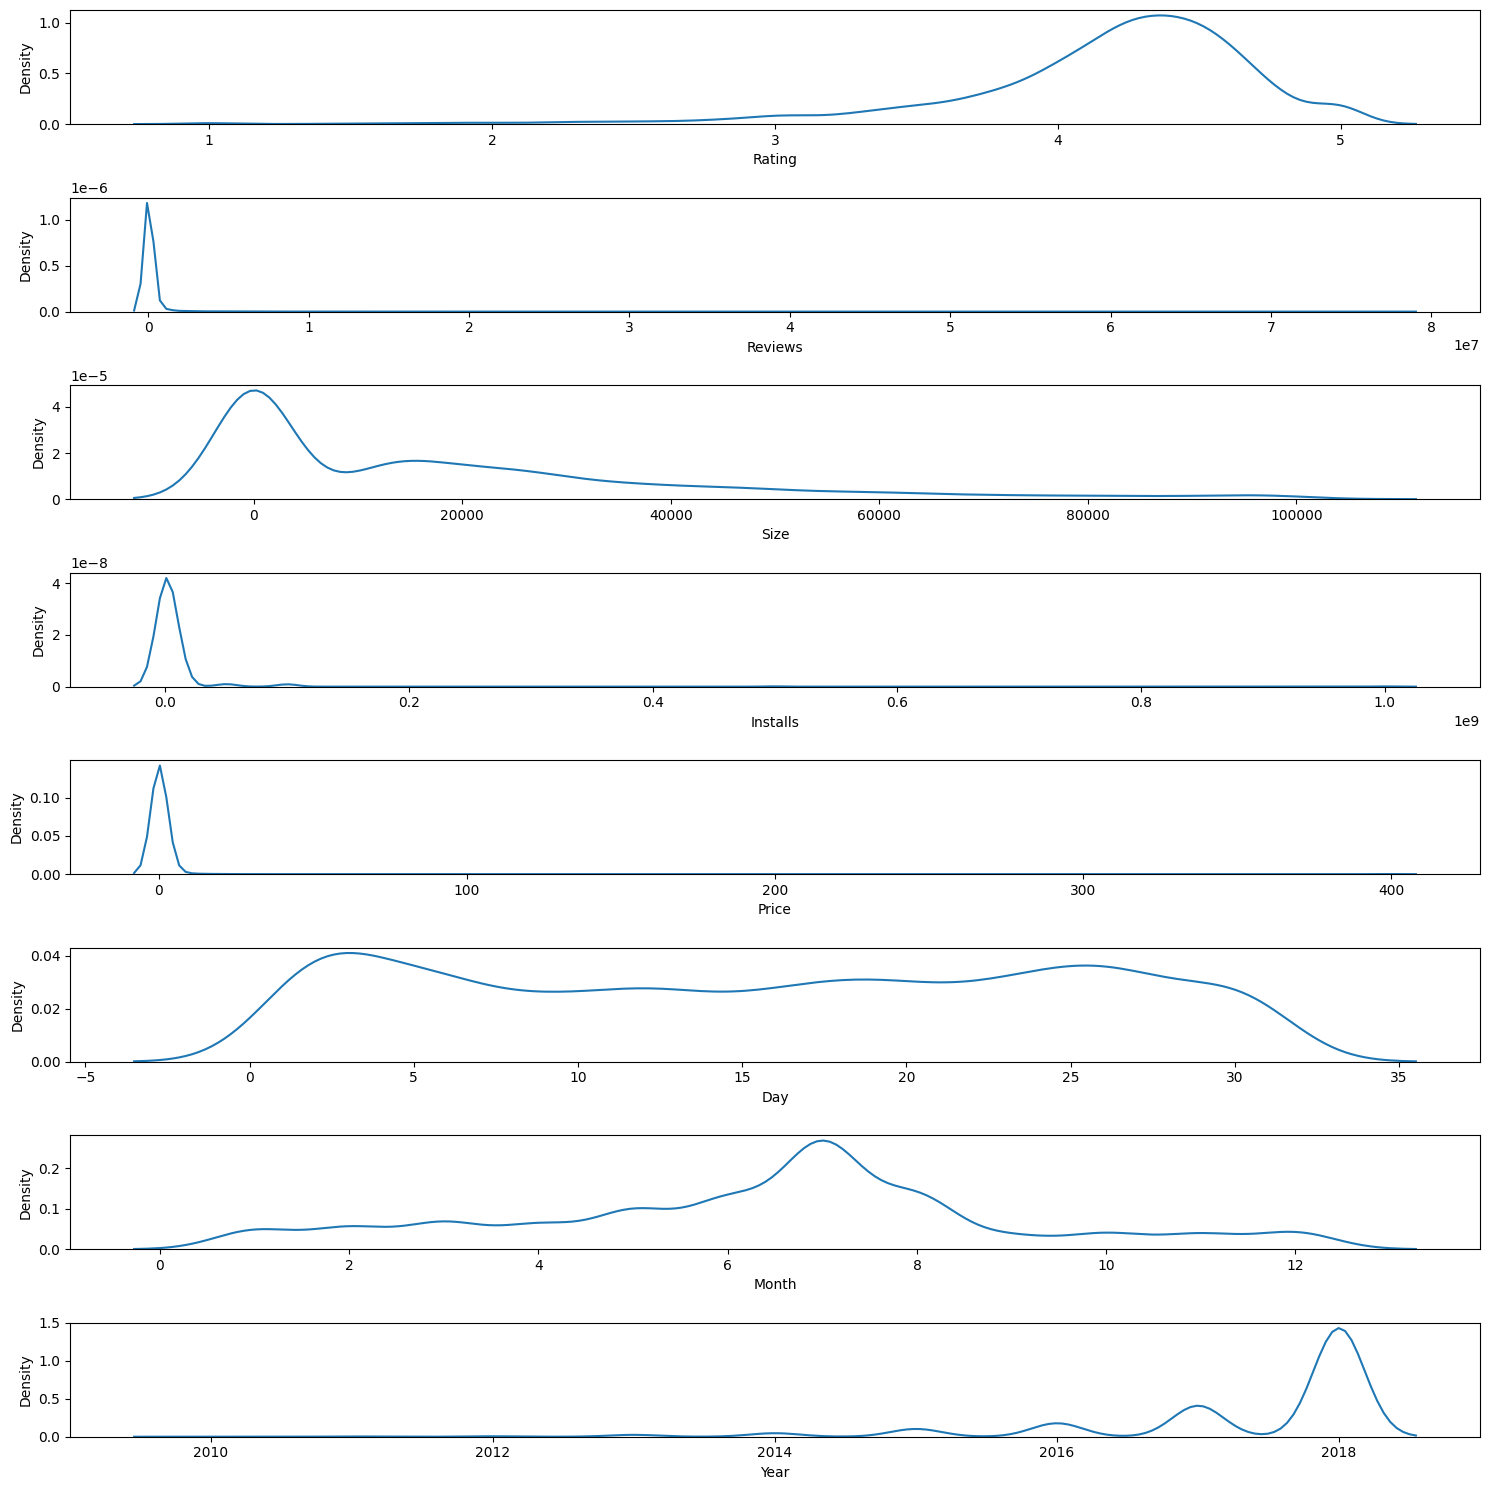

In [69]:
plt.figure(figsize=(15,15))
for i, feature in enumerate(num_cols):
    plt.subplot(len(num_cols),1,i+1)
    sns.kdeplot(df[feature])
    
plt.tight_layout()
plt.show()

Now we will do for categorical features

C:\Users\ssa56\AppData\Local\Temp\ipykernel_2540\3576289400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=df_copy, palette='Set2')


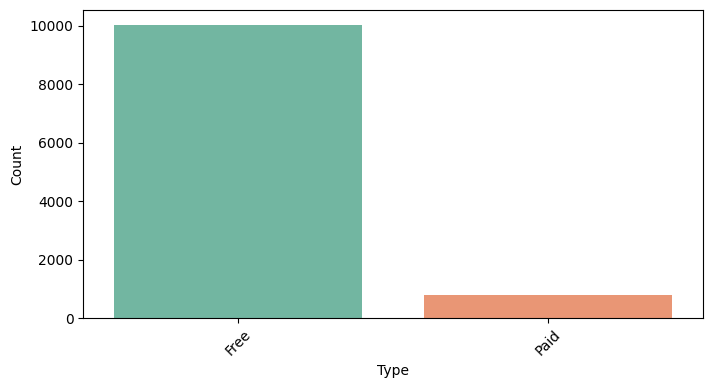

C:\Users\ssa56\AppData\Local\Temp\ipykernel_2540\3576289400.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Content Rating', data=df_copy, palette='Set2')


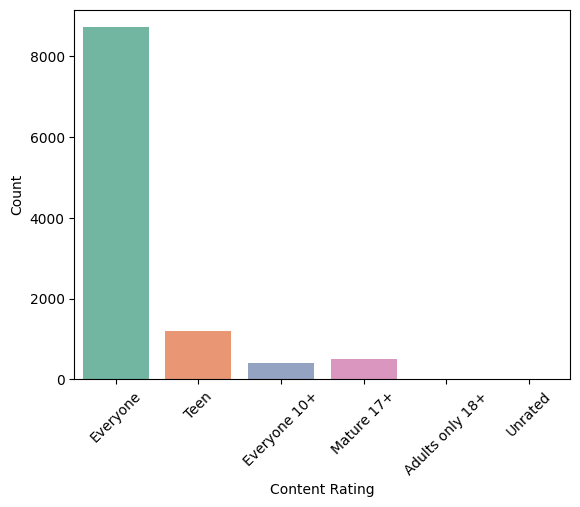

In [71]:
plt.figure(figsize=(8, 4))

sns.countplot(x='Type', data=df_copy, palette='Set2')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

sns.countplot(x='Content Rating', data=df_copy, palette='Set2')
plt.xlabel('Content Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## QUESTIONS
1. Most Popular App Category?
2. Top 10 most popular app categories?
3. Which category has the largest number of installations?
4. What are the top 5 most installed apps in each popular category?
5. How many apps on the Google Play Store have a 5-star rating?

([<matplotlib.patches.Wedge at 0x22051361d10>,
 [Text(0.6620113388364933, 0.8784878981818213, 'FAMILY'),
  Text(-0.7605473774965761, 0.7947123294520356, 'GAME'),
  Text(-1.0951003863677835, -0.10370700929605121, 'TOOLS'),
  Text(-0.8240415251025276, -0.7286669780542415, 'BUSINESS'),
  Text(-0.46378919549096376, -0.9974465309708811, 'MEDICAL'),
  Text(-0.05052451171005798, -1.0988390572401676, 'PERSONALIZATION'),
  Text(0.3592971969312048, -1.0396660638288524, 'PRODUCTIVITY'),
  Text(0.7152582230236136, -0.8357066916072307, 'LIFESTYLE'),
  Text(0.9640762784934955, -0.529676249463889, 'FINANCE'),
  Text(1.0852227048141183, -0.1796988618659825, 'SPORTS')],
 [Text(0.3610970939108145, 0.47917521719008427, '29.4%'),
  Text(-0.4148440240890415, 0.43347945242838304, '15.4%'),
  Text(-0.5973274834733364, -0.05656745961602793, '13.3%'),
  Text(-0.44947719551046955, -0.3974547153023135, '6.8%'),
  Text(-0.25297592481325293, -0.5440617441659351, '6.3%'),
  Text(-0.02755882456912253, -0.59936675849

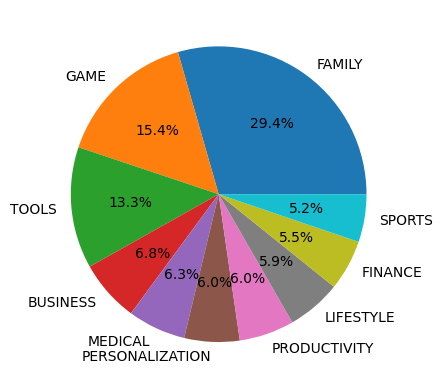

In [79]:
fig, ax = plt.subplots()
label = df['Category'].value_counts().head(10)
ax.pie(label,labels=label.index,autopct='%1.1f%%')

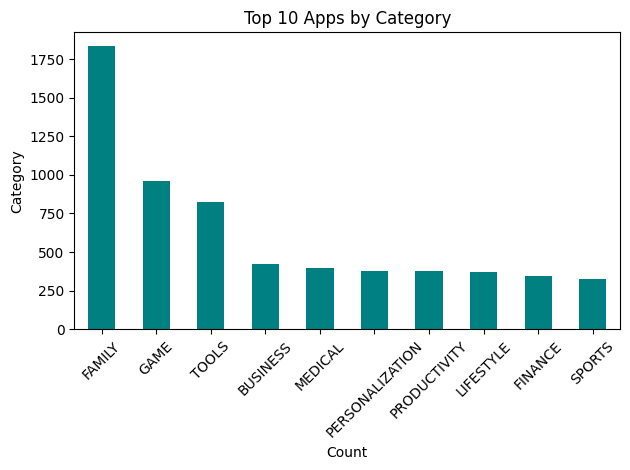

In [81]:
label.plot(kind='bar', color='teal')
plt.xlabel('Count')
plt.ylabel('Category')
plt.title('Top 10 Apps by Category')
plt.xticks(rotation=45) # Rotates the text so names don't overlap
plt.tight_layout()
plt.show()


In [86]:
top_category = df.groupby('Category')['Installs'].sum().sort_values(ascending=False)
print(top_category)

Category
GAME                   13878924415
COMMUNICATION          11038276251
TOOLS                   8001771915
PRODUCTIVITY            5793091369
SOCIAL                  5487867902
PHOTOGRAPHY             4649147655
FAMILY                  4427941505
VIDEO_PLAYERS           3926902720
TRAVEL_AND_LOCAL        2894887146
NEWS_AND_MAGAZINES      2369217760
ENTERTAINMENT           2113660000
BOOKS_AND_REFERENCE     1665969576
PERSONALIZATION         1532494782
SHOPPING                1400348785
HEALTH_AND_FITNESS      1144022512
SPORTS                  1096474498
BUSINESS                 697164865
LIFESTYLE                503823539
MAPS_AND_NAVIGATION      503281890
FINANCE                  455348734
WEATHER                  361100520
EDUCATION                352952000
FOOD_AND_DRINK           211798751
DATING                   140926107
ART_AND_DESIGN           114338100
HOUSE_AND_HOME            97212461
AUTO_AND_VEHICLES         53130211
LIBRARIES_AND_DEMO        52995910
COMICS     

In [87]:
top5_installs = df.sort_values(by='Installs',ascending=False).groupby('Category').head(5)
print(top5_installs[['Category','App','Installs']])

                 Category                                                App  \
3736   NEWS_AND_MAGAZINES                                        Google News   
2554               SOCIAL                                            Google+   
1654                 GAME                                     Subway Surfers   
152   BOOKS_AND_REFERENCE                                  Google Play Books   
3665        VIDEO_PLAYERS                                            YouTube   
...                   ...                                                ...   
3605            PARENTING   Safe365 – Cell Phone GPS Locator For Your Family   
3578            PARENTING                        My baby Game (Balloon POP!)   
119                BEAUTY             Mirror Camera (Mirror + Selfie Camera)   
122                BEAUTY  Sephora: Skin Care, Beauty Makeup & Fragrance ...   
136                BEAUTY                                     Rainbow Camera   

        Installs  
3736  1000000000  
2

In [91]:
fivestar = df.groupby('Rating')['App'].count()
print(fivestar[5.0])

271
